#### TODO:
* split features into raw and t-series (impute as raw, and fillna -1 or 0 for t-series?)
* hypertuning
* add demographic parameters (and string params e.g. ett)
* check feature importance
* (add time series features - covariance? And feature interactions?)
* add feature selection using mlxtend SFS
* trial new sampling/training regime
* include non rfd patients
* improve class size balancing so that we retain all NRFD instances for patients who were declared fit for discharge but had a negative outcome - these are the harder cases, and they are currently being diluted by the other NRFD instances (from earlier in stays).

In [2]:
from umap import UMAP
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
from sklearn.pipeline import Pipeline
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
%matplotlib inline

C:\Users\mcwilliamschr\Documents\SMARTT\sniffer_release\SMARTTDataExtraction\newenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
project_name = 'smartt_bmj_open_plus'

In [4]:
save_to_path = Path(f"E:/SMARTT/data/processed/{project_name}")

In [5]:
final_cohort = pd.read_json('..\data\processed\linked_cohort_181024.json', convert_dates=['admitStoreDateTime', 'dischargeStoreDateTime'])

In [6]:
all_samples = pd.read_csv(save_to_path / f"all_24hr_samples_final_cohort_.csv", low_memory=False)

In [7]:
original_features = [
    'Glasgow Coma Scale_ffill', 'temperature_ffill', 'arterial blood pressure (mean)_ffill', 'Fio2_ffill',
    'arterial oxygen saturation_ffill', 'respiratory rate_ffill', 'Heart rate_ffill', 'actual bicarbonate_ffill',
    'Hemoglobin_ffill', 'platelet count_ffill', 'Sodium_ffill', 'potassium_ffill',
    'creatinine_ffill', 'urea_ffill', 'Bilirubin_ffill', 'positive end-expiratory pressure_ffill', 'hours_since_admission'
]

In [8]:
new_features = [
    c
    for c in all_samples.columns
    if '_ffill' in c and c not in original_features and 'trach' not in c and 'delta' not in c
]

In [9]:
temporal_features = [
    c
    for c in all_samples.columns
    if 'delta' in c
]

In [10]:
all_features = original_features + new_features + temporal_features

In [11]:
all_samples['label'] = [s in ['True', '1', 1] for s in all_samples['label']]

In [12]:
for f in all_samples[original_features + ['hours_since_admission', 'eid'] + new_features + temporal_features]:
    all_samples[f] = pd.to_numeric(all_samples[f], errors='coerce')

In [13]:
 all_samples = all_samples[
     ['time', 'hours_since_admission', 'label', 'eid']
     + all_features
]
# ].dropna()

In [14]:
NNeigh = 5
imputer = KNNImputer(n_neighbors=NNeigh)

In [15]:
impute_features = original_features + new_features
all_samples.loc[:,impute_features] = imputer.fit_transform(all_samples[impute_features])

In [16]:
all_samples.loc[:,temporal_features] = all_samples[temporal_features].fillna(0)

In [17]:
all_samples.groupby('label').count()

,time,hours_since_admission,eid,Glasgow Coma Scale_ffill,temperature_ffill,arterial blood pressure (mean)_ffill,Fio2_ffill,arterial oxygen saturation_ffill,respiratory rate_ffill,Heart rate_ffill,...,creatinine_ffill_delta_3,urea_ffill_delta_1,urea_ffill_delta_2,urea_ffill_delta_3,Bilirubin_ffill_delta_1,Bilirubin_ffill_delta_2,Bilirubin_ffill_delta_3,positive end-expiratory pressure_ffill_delta_1,positive end-expiratory pressure_ffill_delta_2,positive end-expiratory pressure_ffill_delta_3
label,,,,,,,,,,,,,,,,,,,,,
False,16796,16807,16796,16807,16807,16807,16807,16807,16807,16807,...,16807,16807,16807,16807,16807,16807,16807,16807,16807,16807
True,4129,4129,4129,4129,4129,4129,4129,4129,4129,4129,...,4129,4129,4129,4129,4129,4129,4129,4129,4129,4129


In [18]:
scaler = StandardScaler()

In [19]:
scaled_samples = all_samples.copy()
# scaled_samples[original_features] = scaler.fit_transform(scaled_samples[original_features])
scaled_samples[all_features] = scaler.fit_transform(scaled_samples[all_features])

In [20]:
desired_class_size = len(scaled_samples[scaled_samples.label==1])

In [21]:
scaled_samples = pd.concat([
    scaled_samples[scaled_samples.label==1],
    scaled_samples[scaled_samples.label==0].sample(n=desired_class_size)
])

In [22]:
train, test = train_test_split(final_cohort[final_cohort['Declared clinically ready for discharge']=='Yes'], test_size=0.2)

In [23]:
# train, test = train_test_split(scaled_samples, test_size=0.2)
train = scaled_samples[scaled_samples.eid.isin(train.encounterId)]
test = scaled_samples[scaled_samples.eid.isin(test.encounterId)]

In [24]:
# selected_features = [all_features[f] for f in sfs1.k_feature_idx_]
# print(selected_features)
# len(selected_features)

In [31]:
reducer = UMAP(n_jobs=-1, n_neighbors=50, min_dist=0.2)

In [32]:
embedding = reducer.fit_transform(scaled_samples[all_features])

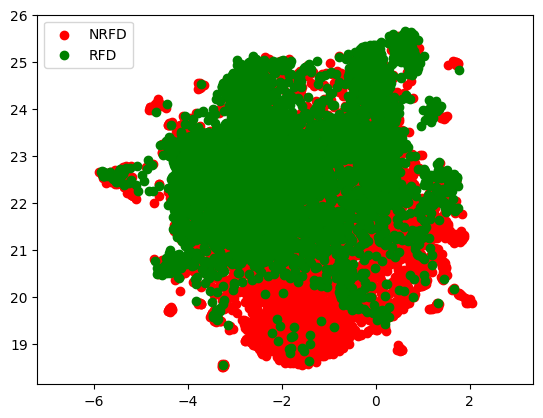

In [33]:
plt.scatter(
    embedding[scaled_samples.label==0,0],
    embedding[scaled_samples.label==0,1],
    label='NRFD',
    color='r'
)
plt.scatter(
    embedding[scaled_samples.label==1,0],
    embedding[scaled_samples.label==1,1],
    label='RFD',
    color='g'
)
plt.legend()
plt.gca().set_aspect('equal', 'datalim')